<h1 style='color:purple' align='center'>Data Science Regression Project: Predicting Home Prices in Banglore</h1>

Dataset is downloaded from here: https://www.kaggle.com/amitabhajoy/bengaluru-house-price-data

In [1]:
import pandas as pd
# To display DataFrame values without scientific notation (i.e., without powers of 10)
# Add this code before displaying your DataFrame or Series. This will show numbers in standard decimal format instead of scientific notation.
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib 
matplotlib.rcParams["figure.figsize"] = (20,10)

<h2 style='color:blue'>Data Load: Load banglore home prices into a dataframe</h2>

In [2]:
df1 = pd.read_csv("bengaluru_house_prices.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.00,1.00,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.00,3.00,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.00,3.00,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.00,1.00,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.00,1.00,51.00


In [3]:
df1.shape

(13320, 9)

In [4]:
df1.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df1['area_type'].nunique()

4

In [6]:
df1['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [7]:
df1.groupby('area_type')['area_type'].agg('count')
# Same as df1['area_type'].value_counts()

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [8]:
df1['area_type'].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [9]:
df1['area_type'].value_counts(normalize=True)*100

area_type
Super built-up  Area   65.99
Built-up  Area         18.15
Plot  Area             15.20
Carpet  Area            0.65
Name: proportion, dtype: float64

In [10]:
df1.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

**Drop features that are not required to build our model**

In [11]:
df2 = df1.drop(['area_type','society','balcony','availability'],axis='columns')
df2.shape

(13320, 5)

In [12]:
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.00,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.00,120.00
2,Uttarahalli,3 BHK,1440,2.00,62.00
3,Lingadheeranahalli,3 BHK,1521,3.00,95.00
4,Kothanur,2 BHK,1200,2.00,51.00


<h2 style='color:blue'>Data Cleaning: Handle NA values</h2>

In [13]:
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [14]:
df2.shape

(13320, 5)

In [15]:
df3 = df2.dropna()
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [16]:
df3.shape

(13246, 5)

<h2 style='color:blue'>Feature Engineering</h2>

In [17]:
df3['size'].unique()
# Some values are like 2 BHK, some are 4 Bedroom etc.

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

**Add new feature(integer) for bhk (Bedrooms Hall Kitchen)**

In [18]:
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0])) # It will split the string and take first part and convert it to integer
df3.bhk.unique()

C:\Users\subin\AppData\Local\Temp\ipykernel_7216\3212520389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0])) # It will split the string and take first part and convert it to integer


array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [19]:
df3['size'].unique() # Size is still there, we have to drop it later.

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [20]:
df3['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [21]:
df3[df3.bhk > 20]
# Above are some outliers where bhk is more than 20. We will remove them
# It is impossible to have 2400 total_sqft for 43 BHK house

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.00,230.00,27
4684,Munnekollal,43 Bedroom,2400,40.00,660.00,43


#### Outlier detection methods like z-score, 3SD, and IQR are mainly for numerical columns.    

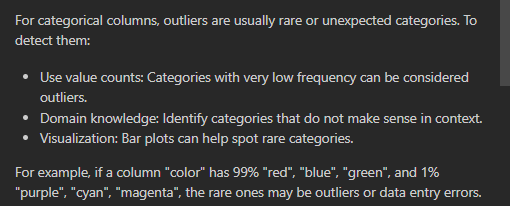

In [22]:
df_outliers = df3.copy()

In [23]:
# # Outlier Removal Using Z Score
# from scipy.stats import zscore

# # Calculate z-scores for the 'bhk' column
# bhk_z_scores = zscore(df_outliers['bhk'])

# # print (bhk_z_scores)

# # Add z-scores as a new column for inspection (optional)
# df_outliers['bhk_zscore'] = bhk_z_scores

# # Filter out rows where the absolute z-score is greater than 3 (outliers)
# df_outliers_no_bhk_z_score = df_outliers[abs(df_outliers['bhk_zscore']) < 3]

# # Check unique bhk values after outlier removal
# df_outliers_no_bhk_z_score['bhk'].unique()

In [24]:
# df_outliers.shape

In [25]:
# df_outliers_no_bhk_z_score.shape

* 3 SD: Commonly used, less strict, only the most extreme values (about 0.3% of data in a normal distribution) are considered outliers. This is safer for most real-world data, as it avoids removing too many valid points.

* 2 SD: More strict, flags more points as outliers (about 5% of data in a normal distribution). Use this if you want to catch more potential anomalies, but it may remove some valid data.

In [26]:
# # Remove outliers in 'bhk' using 3 standard deviations
# bhk_mean = df_outliers['bhk'].mean()
# bhk_std = df_outliers['bhk'].std()
# df_outliers_no_bhk_outliers_3sd = df_outliers[(df_outliers['bhk'] > (bhk_mean - 3*bhk_std)) & (df_outliers['bhk'] < (bhk_mean + 3*bhk_std))]
# df_outliers_no_bhk_outliers_3sd['bhk'].unique()

In [27]:
# # Remove outliers in 'bhk' using IQR method
# Q1 = df_outliers['bhk'].quantile(0.25)
# Q3 = df_outliers['bhk'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# df_outliers_no_bhk_outliers_iqr = df_outliers[(df_outliers['bhk'] >= lower_bound) & (df_outliers['bhk'] <= upper_bound)]
# df_outliers_no_bhk_outliers_iqr['bhk'].unique()

In [28]:
# from sklearn.cluster import DBSCAN
# import numpy as np

# # Reshape bhk column for DBSCAN (expects 2D array)
# bhk_values = df_outliers['bhk'].values.reshape(-1, 1)

# # Fit DBSCAN
# dbscan = DBSCAN(eps=1, min_samples=5)  # You may need to tune eps and min_samples
# labels = dbscan.fit_predict(bhk_values)

# # Outliers are labeled as -1
# df_outliers['bhk_dbscan_label'] = labels
# df_outliers_bhk_dbscan_outliers = df_outliers[df_outliers['bhk_dbscan_label'] == -1]
# df_outliers_bhk_dbscan_inliers = df_outliers[df_outliers['bhk_dbscan_label'] != -1]

# # Unique bhk values after removing DBSCAN outliers
# df_outliers_bhk_dbscan_inliers['bhk'].unique()

In [29]:
float(3)

3.0

**Explore total_sqft feature**

In [30]:
def is_float(x):
    # If values in a column can be converted to float, return True else False
    try:
        float(x)
    except:
        return False
    return True

In [31]:
# Count values in 'total_sqft' that are not numerical
non_numerical_count = df3[~df3['total_sqft'].apply(is_float)].shape[0]
print(non_numerical_count)

190


In [32]:
df3.shape

(13246, 6)

In [33]:
df3[~df3['total_sqft'].apply(is_float)].head(10)
# Above are some rows which are not in proper format. We will remove them

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.00,186.00,4
122,Hebbal,4 BHK,3067 - 8156,4.00,477.00,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.00,54.01,2
165,Sarjapur,2 BHK,1145 - 1340,2.00,43.49,2
188,KR Puram,2 BHK,1015 - 1540,2.00,56.80,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.00,18.50,1
549,Hennur Road,2 BHK,1195 - 1440,2.00,63.77,2
648,Arekere,9 Bedroom,4125Perch,9.00,265.00,9
661,Yelahanka,2 BHK,1120 - 1145,2.00,48.13,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.00,445.00,4


**Above shows that total_sqft can be a range (e.g. 2100-2850). For such case we can just take average of min and max value in the range. There are other cases such as 34.46Sq. Meter which one can convert to square ft using unit conversion. I am going to just drop such corner cases to keep things simple**

In [34]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    # print(tokens)
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    else:
        try:
            return float(x)
        except:
            return None

In [35]:
df4 = df3.copy()

In [36]:
# Apply the conversion function to the 'total_sqft' column
df4.total_sqft = df4.total_sqft.apply(convert_sqft_to_num)

In [37]:
# Count values in 'total_sqft' that are not numerical
non_numerical_count = df4[~df4['total_sqft'].apply(is_float)].shape[0]
print(non_numerical_count)

0


In [38]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13200 non-null  float64
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bhk         13246 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 724.4+ KB


In [39]:
print(df4['total_sqft'].isnull().sum())
# 46 NaN rows

46


In [40]:
df4 = df4[df4.total_sqft.notnull()] # Remove rows with NaN in 'total_sqft'
df4.head(2)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.00,2.00,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.00,5.00,120.00,4


In [41]:
print(df4['total_sqft'].isnull().sum())

0


**For below row, it shows total_sqft as 2475 which is an average of the range 2100-2850**   

(2100+2850)/2 = 2475

In [42]:
df4.loc[30] # Check a specific row

location      Yelahanka
size              4 BHK
total_sqft      2475.00
bath               4.00
price            186.00
bhk                   4
Name: 30, dtype: object

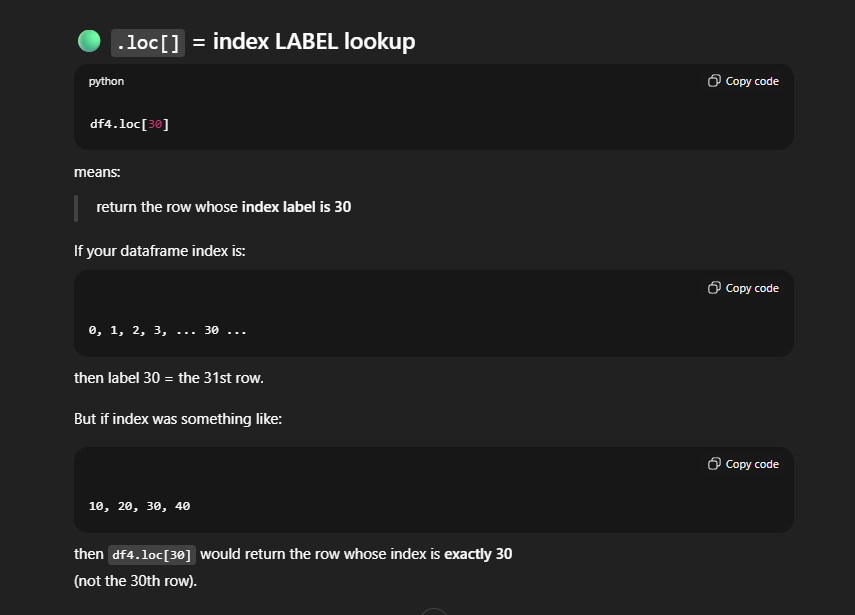

In [43]:
df4.iloc[30] # Check a specific row

location      Yelahanka
size              4 BHK
total_sqft      2475.00
bath               4.00
price            186.00
bhk                   4
Name: 30, dtype: object

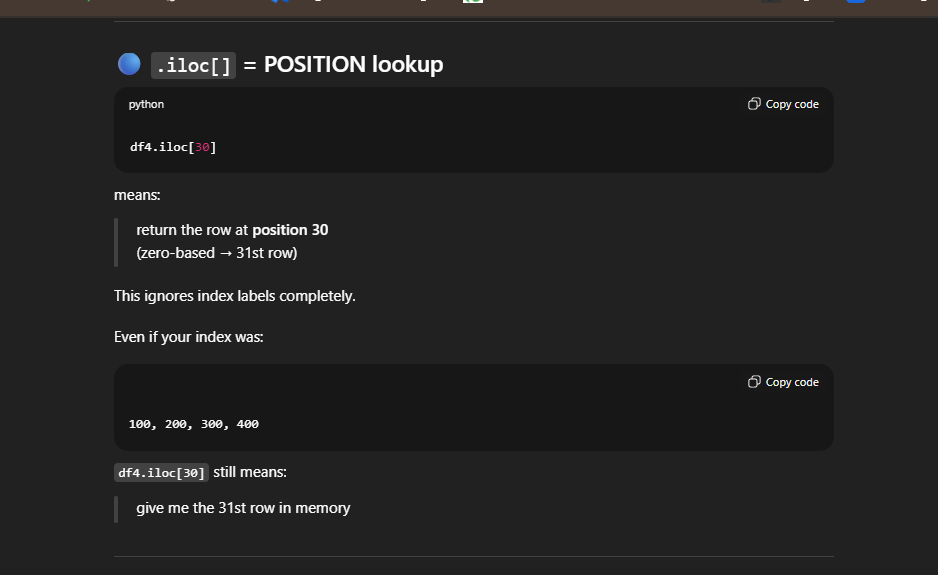

<h2 style="color:blue">Feature Engineering</h2>

**Add new feature called price per square feet**

In [44]:
df5 = df4.copy()

In [45]:
df5.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.00,2.00,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.00,5.00,120.00,4
2,Uttarahalli,3 BHK,1440.00,2.00,62.00,3
3,Lingadheeranahalli,3 BHK,1521.00,3.00,95.00,3
4,Kothanur,2 BHK,1200.00,2.00,51.00,2


In [46]:
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']

In [47]:
df5.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.00,13200.00,13200.00,13200.00,13200.00
mean,1555.30,2.69,112.28,2.80,7920.76
std,1237.32,1.34,149.18,1.29,106727.16
min,1.00,1.00,8.00,1.00,267.83
25%,1100.00,2.00,50.00,2.00,4267.70
50%,1275.00,2.00,71.85,3.00,5438.33
75%,1672.00,3.00,120.00,3.00,7317.07
max,52272.00,40.00,3600.00,43.00,12000000.00


The multiplication by 100,000 is used because the 'price' column in your dataset represents the price in lakhs (1 lakh = 100,000). To calculate the price per square foot in rupees, you need to convert the price from lakhs to rupees by multiplying by 100,000, then divide by the total square feet.   

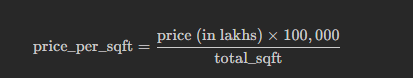   

gives you the price per square foot in rupees.

In [48]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.00,2.00,39.07,2,3699.81
1,Chikka Tirupathi,4 Bedroom,2600.00,5.00,120.00,4,4615.38
2,Uttarahalli,3 BHK,1440.00,2.00,62.00,3,4305.56
3,Lingadheeranahalli,3 BHK,1521.00,3.00,95.00,3,6245.89
4,Kothanur,2 BHK,1200.00,2.00,51.00,2,4250.00


In [49]:
df5.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.00,13200.00,13200.00,13200.00,13200.00
mean,1555.30,2.69,112.28,2.80,7920.76
std,1237.32,1.34,149.18,1.29,106727.16
min,1.00,1.00,8.00,1.00,267.83
25%,1100.00,2.00,50.00,2.00,4267.70
50%,1275.00,2.00,71.85,3.00,5438.33
75%,1672.00,3.00,120.00,3.00,7317.07
max,52272.00,40.00,3600.00,43.00,12000000.00


In [50]:
df5_stats = df5['price_per_sqft'].describe()
df5_stats

count      13200.00
mean        7920.76
std       106727.16
min          267.83
25%         4267.70
50%         5438.33
75%         7317.07
max     12000000.00
Name: price_per_sqft, dtype: float64

In [51]:
df5.to_csv("bhp.csv",index=False)
# bhp = Bangalore Home Prices

In [52]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.00,2.00,39.07,2,3699.81
1,Chikka Tirupathi,4 Bedroom,2600.00,5.00,120.00,4,4615.38
2,Uttarahalli,3 BHK,1440.00,2.00,62.00,3,4305.56
3,Lingadheeranahalli,3 BHK,1521.00,3.00,95.00,3,6245.89
4,Kothanur,2 BHK,1200.00,2.00,51.00,2,4250.00


In [53]:
df5['location'].nunique()

1298

In [54]:
df5['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], shape=(1298,), dtype=object)

In [55]:
df5['location'].value_counts()

location
Whitefield                         532
Sarjapur  Road                     392
Electronic City                    302
Kanakpura Road                     264
Thanisandra                        232
                                  ... 
beml layout, basaveshwara nagar      1
Sadhguru Layout                      1
Chikbasavanapura                     1
Electronic City Phase 1,             1
Chuchangatta Colony                  1
Name: count, Length: 1298, dtype: int64

**Examine locations which is a categorical variable. We need to apply dimensionality reduction technique here to reduce number of locations**

In [56]:
df5.shape

(13200, 7)

In [57]:
df5.location = df5.location.apply(lambda x: x.strip()) # Remove leading and trailing spaces

In [58]:
df5.shape

(13200, 7)

In [59]:
location_stats = df5['location'].value_counts(ascending=False)
location_stats

location
Whitefield                           533
Sarjapur  Road                       392
Electronic City                      304
Kanakpura Road                       264
Thanisandra                          235
                                    ... 
Zuzuvadi                               1
Chellikere                             1
Jakkasandra                            1
Gulakamale                             1
Beml layout, Rajarajeshwari nagar      1
Name: count, Length: 1287, dtype: int64

In [60]:
type(location_stats)

pandas.core.series.Series

In [61]:
print(location_stats.values.sum())

13200


In [62]:
len(location_stats[location_stats>10])

240

In [63]:
s = location_stats[location_stats>10]

In [64]:
s.head()

location
Whitefield         533
Sarjapur  Road     392
Electronic City    304
Kanakpura Road     264
Thanisandra        235
Name: count, dtype: int64

In [65]:
s.shape

(240,)

In [66]:
m = location_stats[location_stats<=10]

In [67]:
m.head()

location
Ganga Nagar              10
Kalkere                  10
Dairy Circle             10
1st Block Koramangala    10
Sector 1 HSR Layout      10
Name: count, dtype: int64

In [68]:
m.shape

(1047,)

In [69]:
len(location_stats)

1287

In [70]:
len(location_stats[location_stats<=10])

1047

<h2 style="color:blue">Dimensionality Reduction (Cardinality reduction of a categorical variable.)</h2>

**Any location having less than or equal to 10 data points should be tagged as "other" location. This way number of categories can be reduced by huge amount. Later on when we do one hot encoding, it will help us with having fewer dummy columns**

In [71]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

location
Ganga Nagar                          10
Kalkere                              10
Dairy Circle                         10
1st Block Koramangala                10
Sector 1 HSR Layout                  10
                                     ..
Zuzuvadi                              1
Chellikere                            1
Jakkasandra                           1
Gulakamale                            1
Beml layout, Rajarajeshwari nagar     1
Name: count, Length: 1047, dtype: int64

In [72]:
location_stats_less_than_10.nunique()

10

In [73]:
location_stats_less_than_10.shape

(1047,)

In [74]:
df5.location.nunique()

1287

In [75]:
df5.location.nunique() - location_stats_less_than_10.shape[0]

240

In [76]:
# 240 + 1 (other locations combined as 'other')

In [77]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df5.location.unique())

241

In [78]:
df5.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.00,13200.00,13200.00,13200.00,13200.00
mean,1555.30,2.69,112.28,2.80,7920.76
std,1237.32,1.34,149.18,1.29,106727.16
min,1.00,1.00,8.00,1.00,267.83
25%,1100.00,2.00,50.00,2.00,4267.70
50%,1275.00,2.00,71.85,3.00,5438.33
75%,1672.00,3.00,120.00,3.00,7317.07
max,52272.00,40.00,3600.00,43.00,12000000.00


In [79]:
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.00,2.00,39.07,2,3699.81
1,Chikka Tirupathi,4 Bedroom,2600.00,5.00,120.00,4,4615.38
2,Uttarahalli,3 BHK,1440.00,2.00,62.00,3,4305.56
3,Lingadheeranahalli,3 BHK,1521.00,3.00,95.00,3,6245.89
4,Kothanur,2 BHK,1200.00,2.00,51.00,2,4250.00
5,Whitefield,2 BHK,1170.00,2.00,38.00,2,3247.86
6,Old Airport Road,4 BHK,2732.00,4.00,204.00,4,7467.06
7,Rajaji Nagar,4 BHK,3300.00,4.00,600.00,4,18181.82
8,Marathahalli,3 BHK,1310.00,3.00,63.25,3,4828.24
9,other,6 Bedroom,1020.00,6.00,370.00,6,36274.51


<h2 style="color:blue">Outlier Removal Using Business Logic</h2>

**As a data scientist when you have a conversation with your business manager (who has expertise in real estate), he will tell you that normally square ft per bedroom is 300 (i.e. 2 bhk apartment is minimum 600 sqft.) If you have for example 400 sqft apartment with 2 bhk than that seems suspicious and can be removed as an outlier. We will remove such outliers by keeping our minimum thresold per bhk to be 300 sqft**

### If a house has bhk (bedroom) = 2 and and total_sqft of 400, then it is outlier.
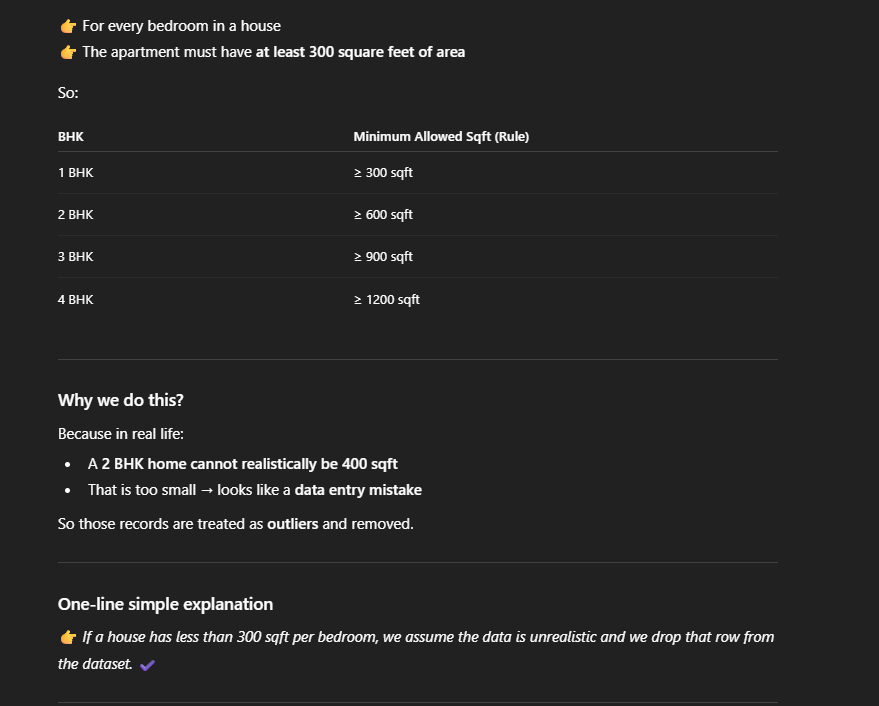

## 2BHK = 2 Bedroom 1 Hall 1 Kitchen

In [80]:
df5[df5.total_sqft/df5.bhk<300].shape

(744, 7)

In [81]:
df5[df5.total_sqft/df5.bhk<300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.00,6.00,370.00,6,36274.51
45,HSR Layout,8 Bedroom,600.00,9.00,200.00,8,33333.33
58,Murugeshpalya,6 Bedroom,1407.00,4.00,150.00,6,10660.98
68,Devarachikkanahalli,8 Bedroom,1350.00,7.00,85.00,8,6296.30
70,other,3 Bedroom,500.00,3.00,100.00,3,20000.00


**Check above data points. We have 6 bhk apartment with 1020 sqft (Real Value = 1800 ). Another one is 8 bhk and total sqft is 600 (Real Value = 2400). These are clear data errors that can be removed safely**

In [82]:
df5.shape

(13200, 7)

In [83]:
df5[df5.total_sqft/df5.bhk<300].shape

(744, 7)

In [84]:
13200 - 744

12456

In [85]:
df5.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.00,13200.00,13200.00,13200.00,13200.00
mean,1555.30,2.69,112.28,2.80,7920.76
std,1237.32,1.34,149.18,1.29,106727.16
min,1.00,1.00,8.00,1.00,267.83
25%,1100.00,2.00,50.00,2.00,4267.70
50%,1275.00,2.00,71.85,3.00,5438.33
75%,1672.00,3.00,120.00,3.00,7317.07
max,52272.00,40.00,3600.00,43.00,12000000.00


### Row with price_per_sqft '12000000' is removed because it has suspicious 43bhk and price is 3600 which supposed to be (43 * 300 = 12,900)

In [86]:
df6 = df5[~(df5.total_sqft/df5.bhk < 300)] # ~ negation operator means not
df6.shape

(12456, 7)

In [87]:
df6.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12456.00,12456.00,12456.00,12456.00,12456.00
mean,1590.19,2.56,111.19,2.65,6308.50
std,1260.40,1.08,152.20,0.98,4168.13
min,300.00,1.00,9.00,1.00,267.83
25%,1115.00,2.00,49.00,2.00,4210.53
50%,1300.00,2.00,70.00,3.00,5294.12
75%,1700.00,3.00,115.00,3.00,6916.67
max,52272.00,16.00,3600.00,16.00,176470.59


<h2 style='color:blue'>Outlier Removal Using Standard Deviation and Mean</h2>

In [88]:
df6.price_per_sqft.describe()

count    12456.00
mean      6308.50
std       4168.13
min        267.83
25%       4210.53
50%       5294.12
75%       6916.67
max     176470.59
Name: price_per_sqft, dtype: float64

**Here we find that min price per sqft is 267.83 rs/sqft whereas max is 176470 rs/sqft, this shows a wide variation in property prices. We should remove outliers per location using mean and one standard deviation**

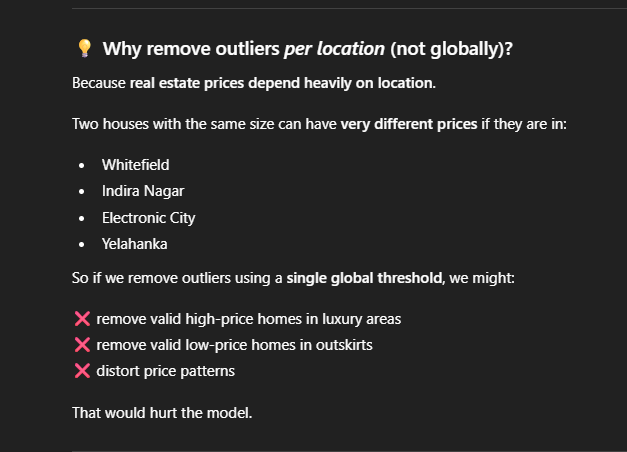

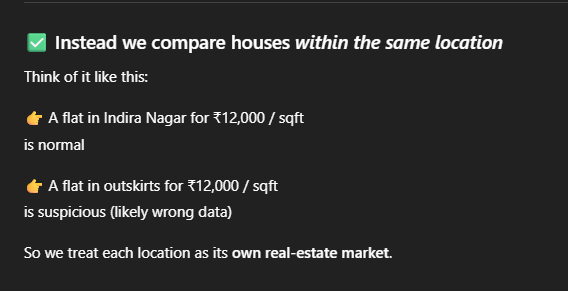

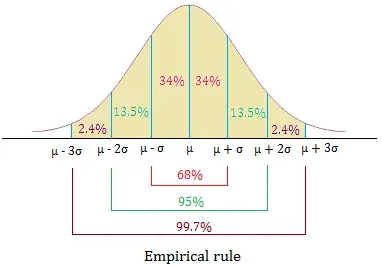

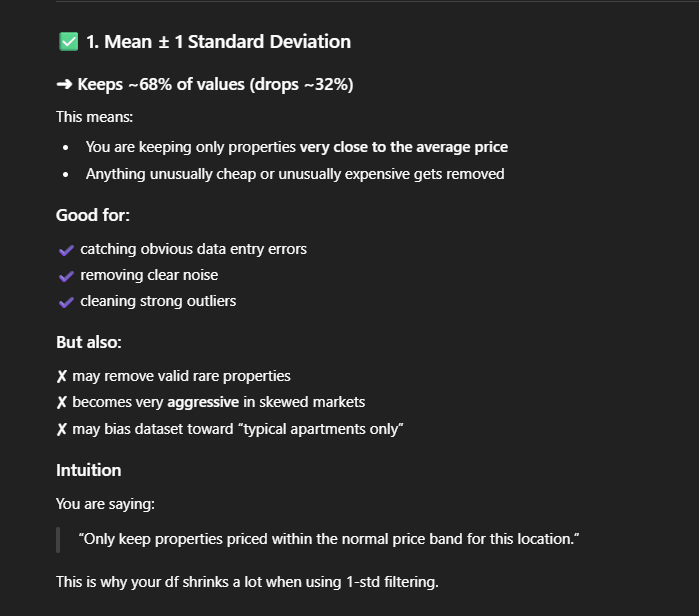  

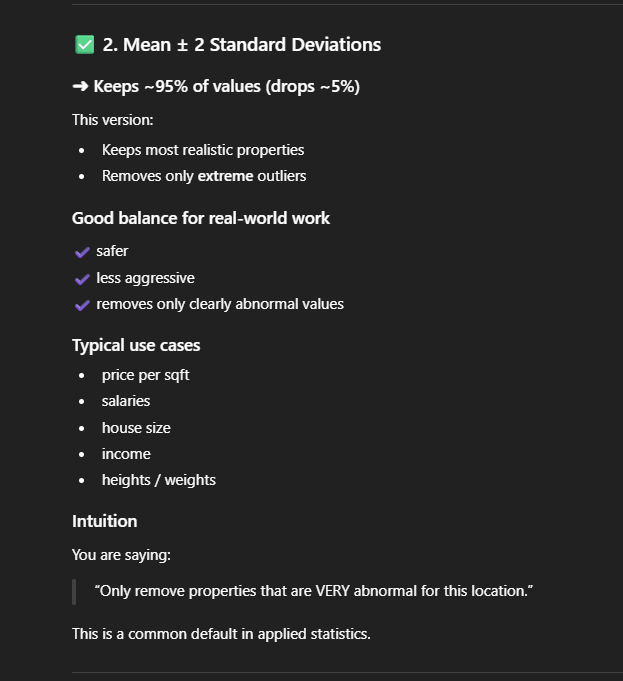  

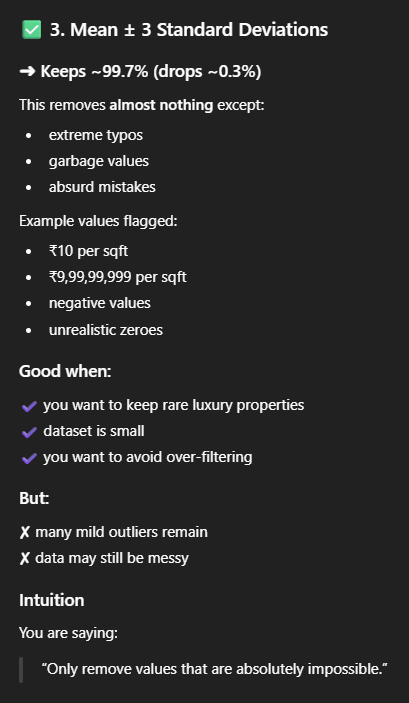  

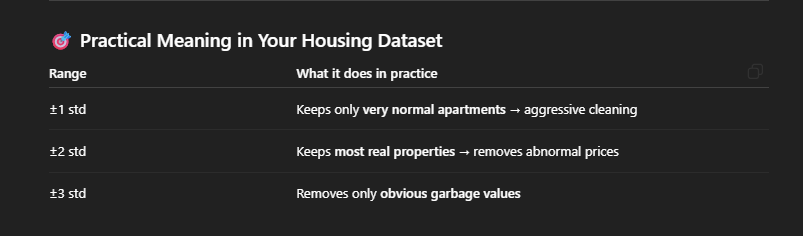  

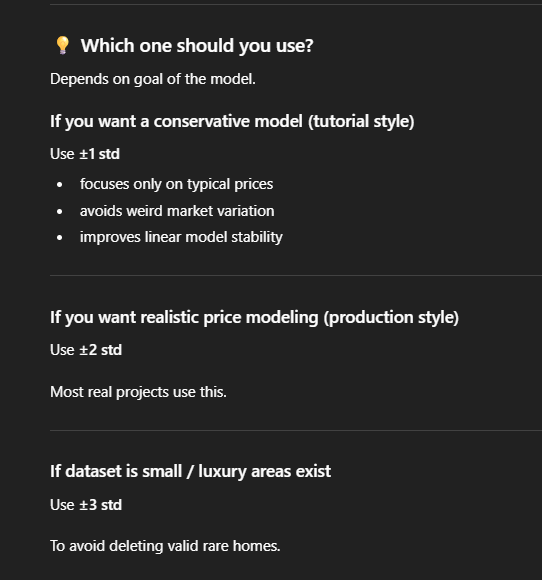  

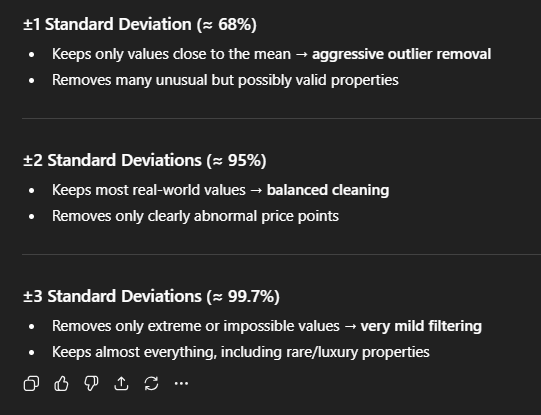

In [89]:
# TESTING
df100 = df6.copy()

In [90]:
# TESTING
df100.groupby('location')

In [91]:
# TESTING
# Count of all rows where location is 1st Block Jayanagar
df100[df100['location'] == '1st Block Jayanagar'].shape[0]

10

In [92]:
# TESTING
# Count of all rows where location is 1st Block Jayanagar
df5[df5['location'] == '1st Block Jayanagar'].shape[0]

14

In [93]:
# TESTING
# key is the location name.
# subdf is a DataFrame containing all rows for that location or key.

for key, subdf in df100.groupby('location'):
    # print(key)
    # print(type(key))
    # print(subdf)
    # print(type(subdf))
    # print(subdf.shape)
    break
    

In [94]:
df6.shape

(12456, 7)

#### Per location, we find the mean and standard deviation and filter out datapoints outside 1 standard deviation, thereby retaining approximately 68% of the data.

In [95]:
# if price_per_sqft in each location was perfectly normally distributed, then yes —
# (m - s, m + s) would keep about 68% of the data and drop roughly 32% (2.4 * 2 + 13.5 * 2 = 31.8 =~ 32%) as outliers.
# (m - 2 * s, m + 2 * s) would keep about 95% of the data and drop roughly 5% (2.4 * 2 = 4.8 =~ 5%) as outliers.
# (m - 3 * s, m + 3 * s) would keep about 99.7% of the data and drop roughly 0.3% (0.15 * 2 = 0.3%) as outliers.
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m - 1 * st)) & (subdf.price_per_sqft<=(m + 1 * st))]
        # Mean: 12359.253757566757
        # Standard Deviation: 3730.1654195657898
        # Mean - 1*SD: 8629.088338000967
        # Mean + 1*SD: 16089.419177132547
        # print(subdf)
        # print("Location:",key)
        # print("Mean:",m)
        # print("Standard Deviation:",st)
        # print("Original shape:",subdf.shape)
        # print("Reduced shape:",reduced_df.shape)
        # print(reduced_df)
        # print()
        # break
        # df_out = pd.concat([df_out,reduced_df],ignore_index=False)
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out


In [96]:
df7 = remove_pps_outliers(df6)

In [97]:
df7.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.00,4.00,428.00,4,15017.54
1,1st Block Jayanagar,3 BHK,1630.00,3.00,194.00,3,11901.84
2,1st Block Jayanagar,3 BHK,1875.00,2.00,235.00,3,12533.33
3,1st Block Jayanagar,3 BHK,1200.00,2.00,130.00,3,10833.33
4,1st Block Jayanagar,2 BHK,1235.00,2.00,148.00,2,11983.81


In [98]:
df7.shape

(10242, 7)

In [99]:
df6.shape[0] - df7.shape[0]
## Number of rows removed after pps outlier removal: 2214
## pps-outlier means price per sqft outlier

2214

**Let's check if for a given location how does the 2 BHK and 3 BHK property prices look like**
*  We will check if the price of 2 BHK is greater than 3 BHK for the same square feet area

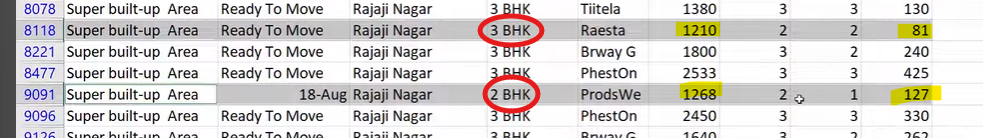    

### Reason 
* Higher buyer demand for 2BHK in that locality makes it commercially more attractive than 3BHK.

* 2BHK units often have better usable carpet area efficiency compared to compact 3BHK layouts.

* The 2BHK unit may be on a better floor, tower, or have a premium view or facing.

* The 2BHK may include better interiors, furnishings, or parking benefits compared to the 3BHK.

* Developers or sellers may discount 3BHK units due to slower sales or distress resale situations.

#### In the above image we take two samples 3BHK and 2BHK, for similiar square feet area and their price are inverted, 3BHK supposed to be be pricier than 2BHK but it is opposite.

## price column represents the total price of the entire apartment, not the price per square foot.  

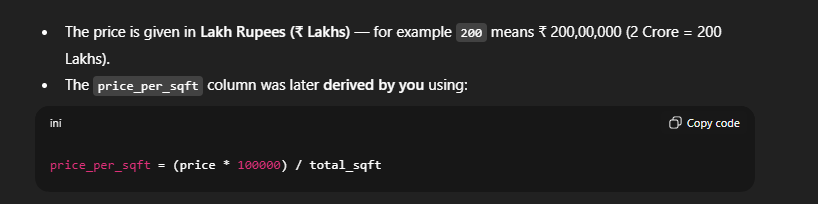

* price → total flat price
* total_sqft → area of the apartment
* price_per_sqft → computed metric for analysis

In [100]:
df7[df7['location'] == 'Rajaji Nagar'].shape[0]

70

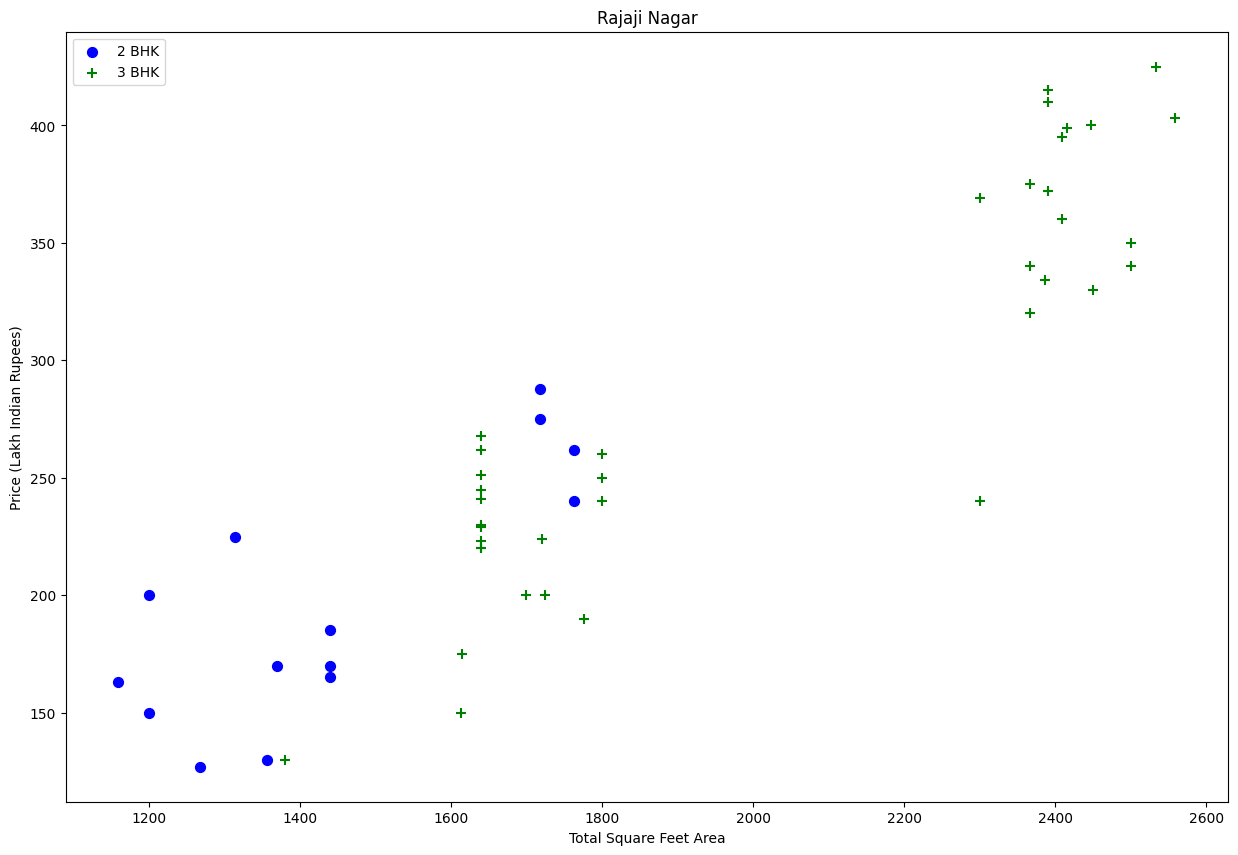

In [101]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df7,"Rajaji Nagar")

#### Report of above Graph

* Most 2 BHK homes are smaller (1200–1800 sqft) and lie in the lower price range.
* Most 3 BHK homes are larger (1600–2600 sqft) and generally cost more than 2 BHK properties.
* However, there is some overlap, meaning a few 3 BHK homes are priced close to larger 2 BHK homes.
* The right-side cluster of green points (high sqft & high price) indicates premium / luxury 3 BHK properties in that location.

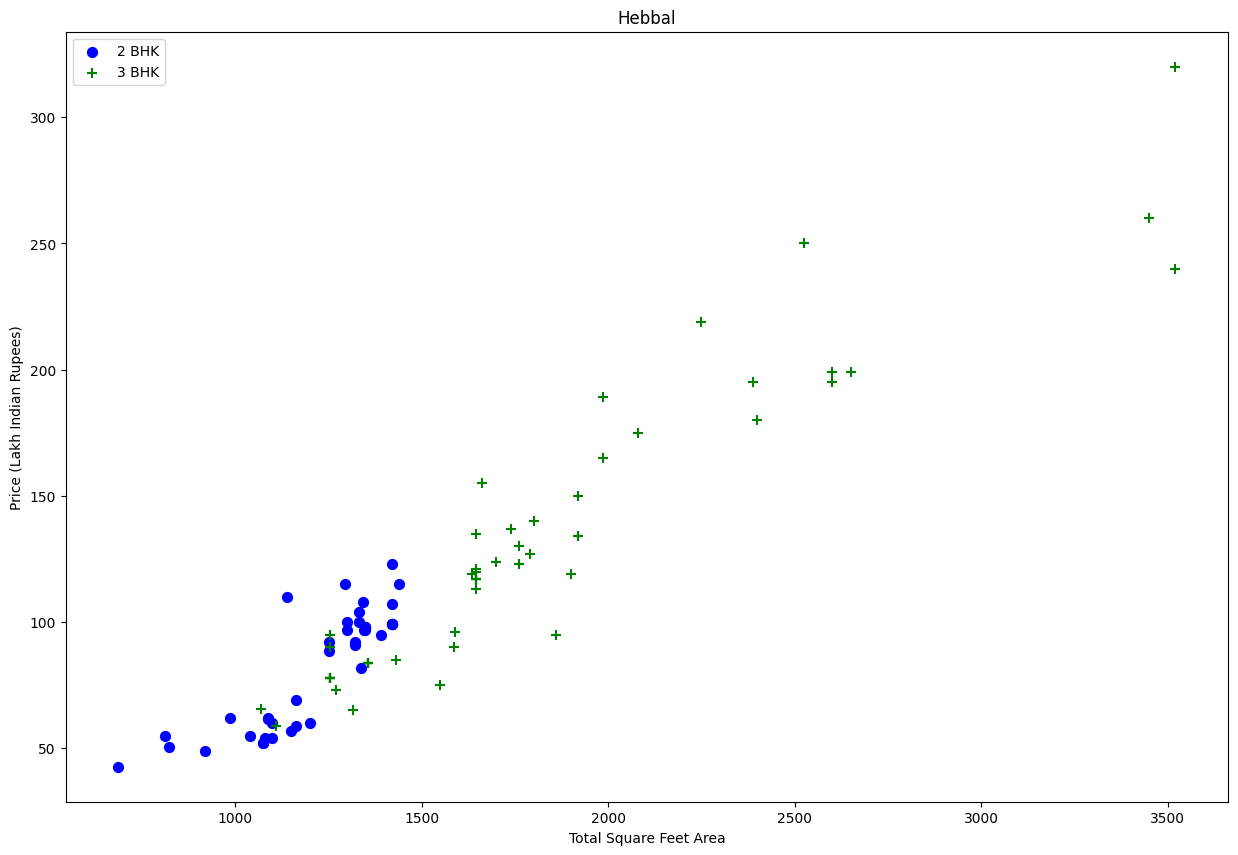

In [102]:
plot_scatter_chart(df7,"Hebbal")

* 2 BHK homes are generally smaller (≈ 800–1400 sqft) and fall in the lower price range.

* 3 BHK homes are larger (≈ 1400–3500 sqft) and trend toward higher prices.

* There is a strong positive correlation between area and price — larger flats cost more.

* Compared to Rajaji Nagar, Hebbal shows a smoother price progression (fewer pricing anomalies).

* Some 3 BHK properties extend far to the right (2500–3500 sqft), indicating premium / villa-style or high-end flats.

* A few lower-priced 3 BHKs overlap with higher-priced 2 BHKs, suggesting variations due to amenities, tower quality, or project brand.

**We should also remove properties where for same location, the price of (for example) 3 bedroom apartment is less than 2 bedroom apartment (with same square ft area). What we will do is for a given location, we will build a dictionary of stats per bhk, i.e.**     
```
{
    '1' : {
        'mean': 4000,
        'std: 2000,
        'count': 34
    },
    '2' : {
        'mean': 4300,
        'std: 2300,
        'count': 22
    },    
}
```
**Now we can remove those 2 BHK apartments whose price_per_sqft is less than mean price_per_sqft of 1 BHK apartment**   

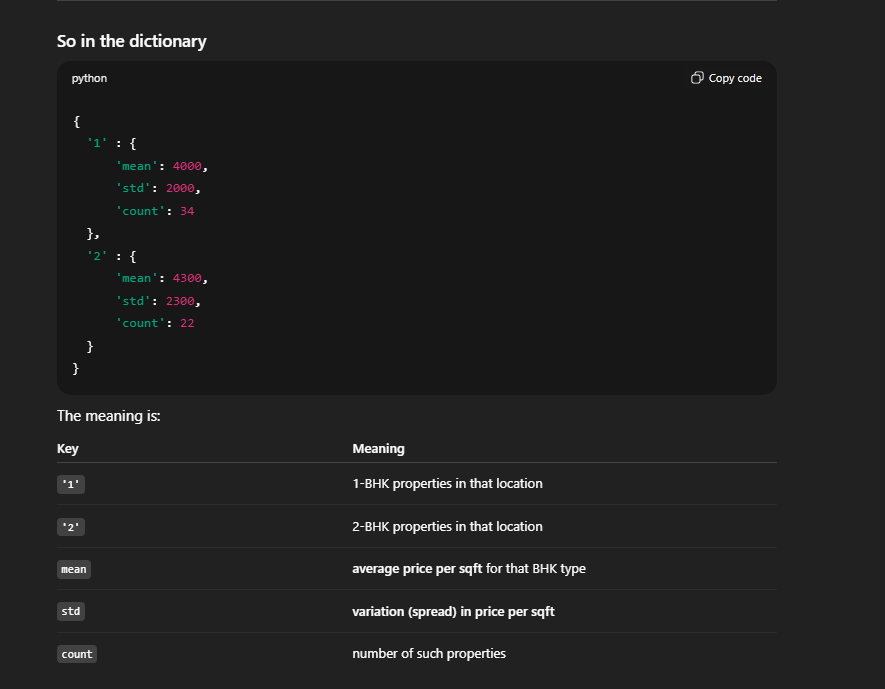   

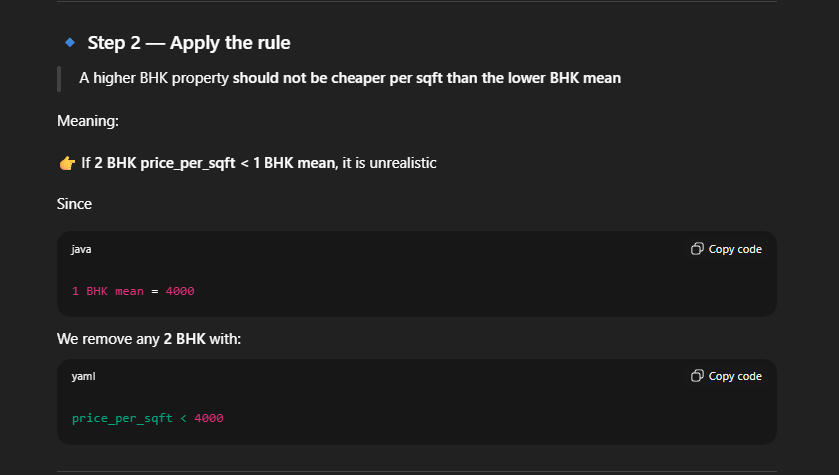

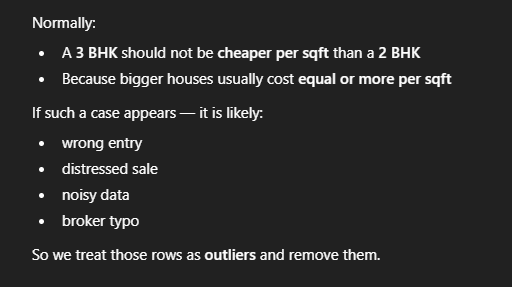  

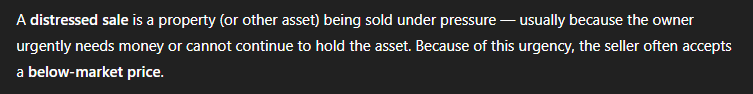

In [103]:
# TESTING
df200 = df7.copy()

In [104]:
# TESTING
df200[df200['location'] == '1st Block Jayanagar'].shape[0]

7

In [105]:
# TESTING
df200[df200['location'] == '1st Block Jayanagar']

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.00,4.00,428.00,4,15017.54
1,1st Block Jayanagar,3 BHK,1630.00,3.00,194.00,3,11901.84
2,1st Block Jayanagar,3 BHK,1875.00,2.00,235.00,3,12533.33
3,1st Block Jayanagar,3 BHK,1200.00,2.00,130.00,3,10833.33
4,1st Block Jayanagar,2 BHK,1235.00,2.00,148.00,2,11983.81
5,1st Block Jayanagar,4 BHK,2750.00,4.00,413.00,4,15018.18
6,1st Block Jayanagar,4 BHK,2450.00,4.00,368.00,4,15020.41


In [106]:
# TESTING
jayanagar = df200[df200['location'] == '1st Block Jayanagar']

In [107]:
# TESTING
for bhk, bhk_df in jayanagar.groupby('bhk'):
    print(bhk)
    print(bhk_df.shape)
    print(bhk_df)
    # break

2
(1, 7)
              location   size  total_sqft  bath  price  bhk  price_per_sqft
4  1st Block Jayanagar  2 BHK     1235.00  2.00 148.00    2        11983.81
3
(3, 7)
              location   size  total_sqft  bath  price  bhk  price_per_sqft
1  1st Block Jayanagar  3 BHK     1630.00  3.00 194.00    3        11901.84
2  1st Block Jayanagar  3 BHK     1875.00  2.00 235.00    3        12533.33
3  1st Block Jayanagar  3 BHK     1200.00  2.00 130.00    3        10833.33
4
(3, 7)
              location   size  total_sqft  bath  price  bhk  price_per_sqft
0  1st Block Jayanagar  4 BHK     2850.00  4.00 428.00    4        15017.54
5  1st Block Jayanagar  4 BHK     2750.00  4.00 413.00    4        15018.18
6  1st Block Jayanagar  4 BHK     2450.00  4.00 368.00    4        15020.41


In [108]:
# TESTING
for location, location_df in df7.groupby('location'):
    print(location)
    print(location_df.shape)
    for bhk, bhk_df in location_df.groupby('bhk'):
        print(bhk)
        print(bhk_df.shape)
    break
        

1st Block Jayanagar
(7, 7)
2
(1, 7)
3
(3, 7)
4
(3, 7)


In [109]:
a = {}
a[1] = 'hello'
print(a)

{1: 'hello'}


In [110]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            # print(location)
            # print(bhk)
            # print(bhk_df.shape)
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
            # print(bhk_stats)
            # print("\n")
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            # print(location)
            # print(bhk)
            # print(stats)
            # print("\n")
            if stats and stats['count'] > 5:
                # In simple terms, stats stores the price_per_sqft statistics of the smaller BHK group in the same location.
                # While checking 2 BHK flats : stats contains the stats of 1 BHK flats in that same location.
                # While checking 3 BHK flats: stats contains the stats of 2 BHK flats.
                # It checks whether this flat’s price per square foot is lower than the average price per square foot of the smaller BHK flats in the same location.
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
        # break
    return df.drop(exclude_indices,axis='index')

# axis='index' (or axis=0) → remove rows by their index numbers
# axis='columns' (or axis=1) → would remove entire columns instead


In [111]:
df8 = remove_bhk_outliers(df7)
df8

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.00,4.00,428.00,4,15017.54
1,1st Block Jayanagar,3 BHK,1630.00,3.00,194.00,3,11901.84
2,1st Block Jayanagar,3 BHK,1875.00,2.00,235.00,3,12533.33
3,1st Block Jayanagar,3 BHK,1200.00,2.00,130.00,3,10833.33
4,1st Block Jayanagar,2 BHK,1235.00,2.00,148.00,2,11983.81
...,...,...,...,...,...,...,...
10233,other,2 BHK,1200.00,2.00,70.00,2,5833.33
10234,other,1 BHK,1800.00,1.00,200.00,1,11111.11
10237,other,2 BHK,1353.00,2.00,110.00,2,8130.08
10238,other,1 Bedroom,812.00,1.00,26.00,1,3201.97


In [112]:
df8.shape

(7317, 7)

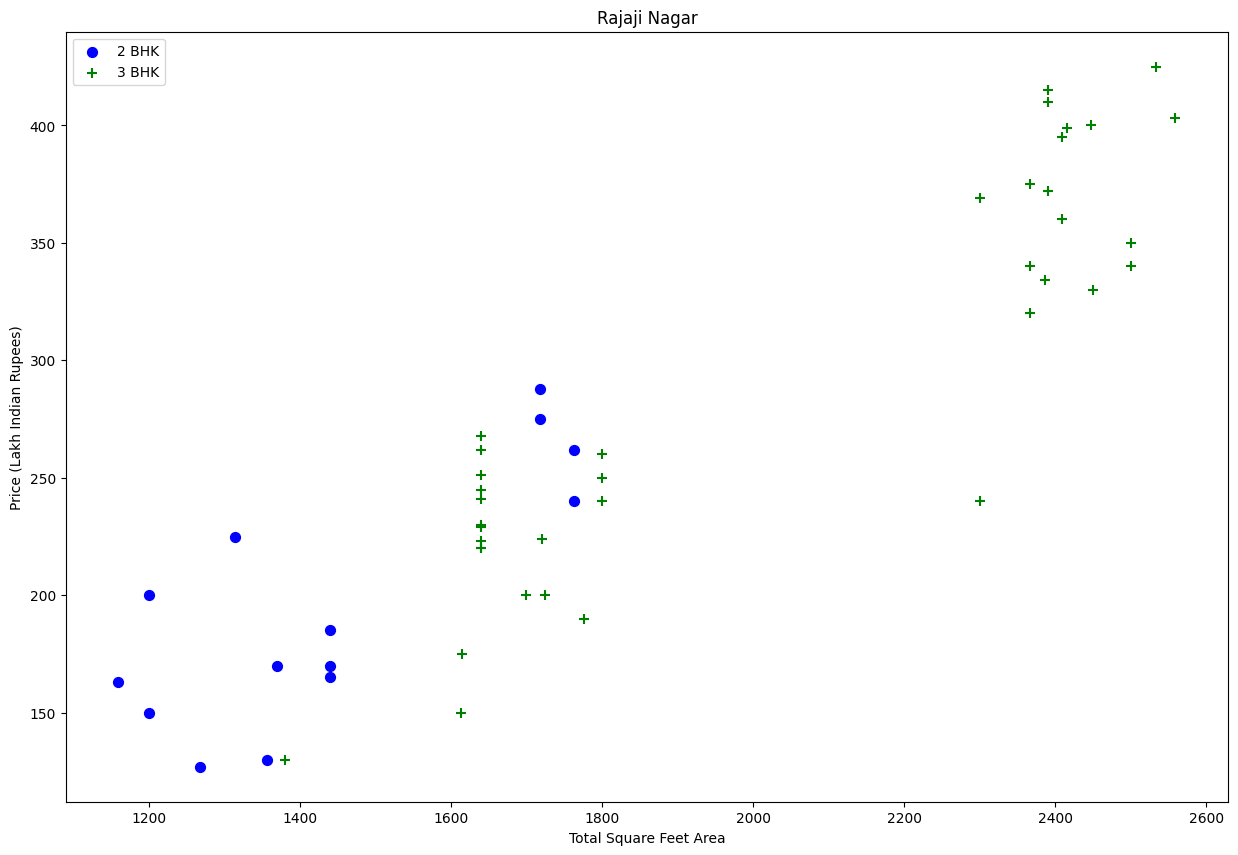

In [113]:
plot_scatter_chart(df7,"Rajaji Nagar")

**Plot same scatter chart again to visualize price_per_sqft for 2 BHK and 3 BHK properties**

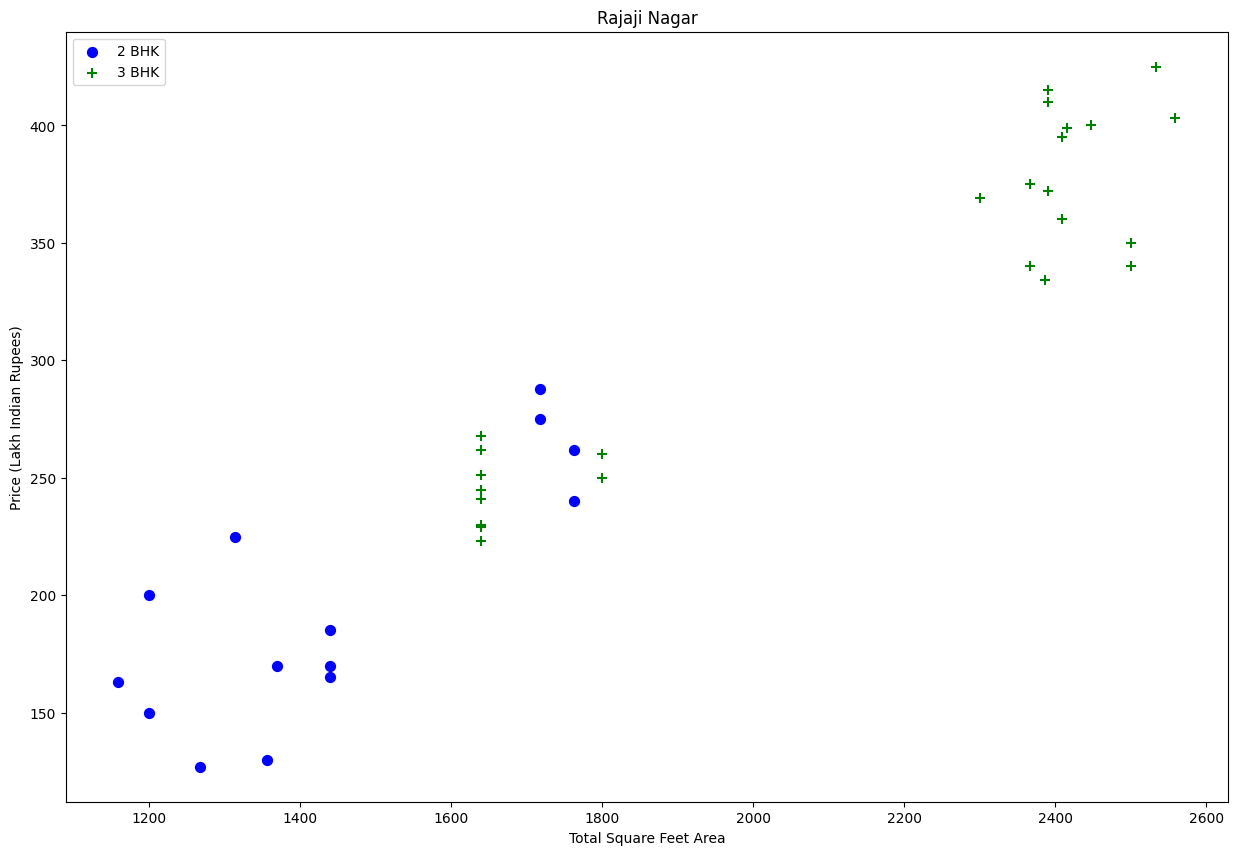

In [114]:
plot_scatter_chart(df8,"Rajaji Nagar")

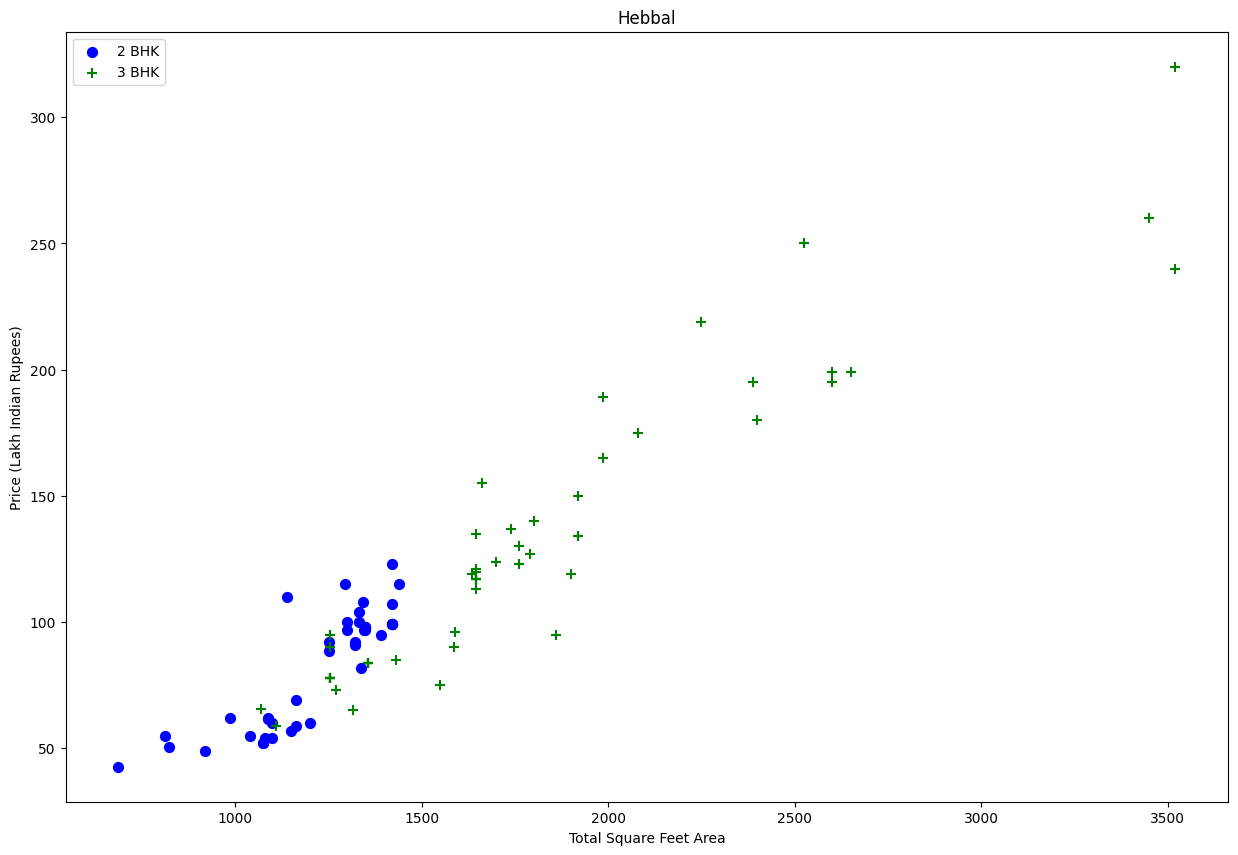

In [115]:
plot_scatter_chart(df7,"Hebbal")

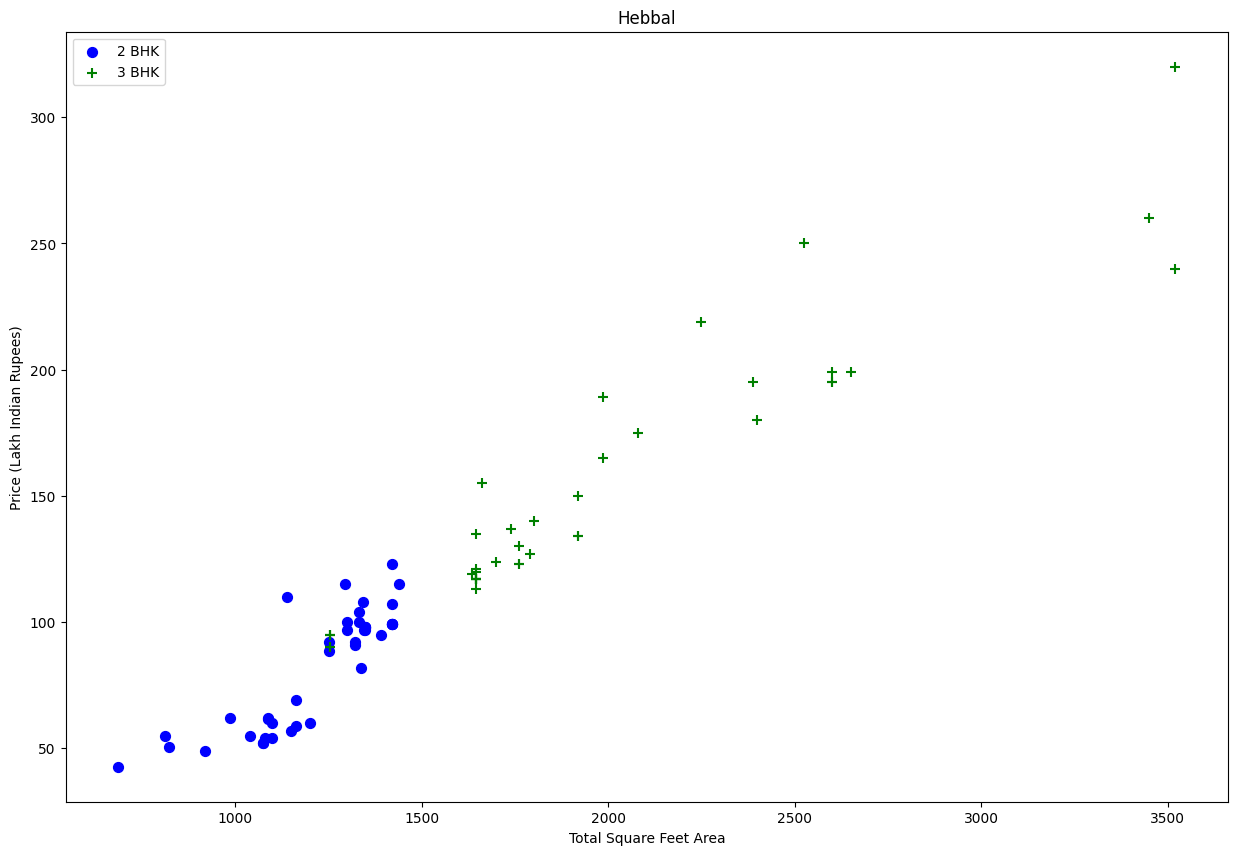

In [116]:
plot_scatter_chart(df8,"Hebbal")

**Based on above charts we can see that data points highlighted in red below are outliers and they are being removed due to remove_bhk_outliers function**

<h3 style='color:green'>Before and after outlier removal: Rajaji Nagar</h3>

<img src="rajaji_nagar_outliers.png"></img>

<h3 style='color:green'>Before and after outlier removal: Hebbal</h3>

<img src="hebbal_outliers.png"></img>

Text(0, 0.5, 'Count')

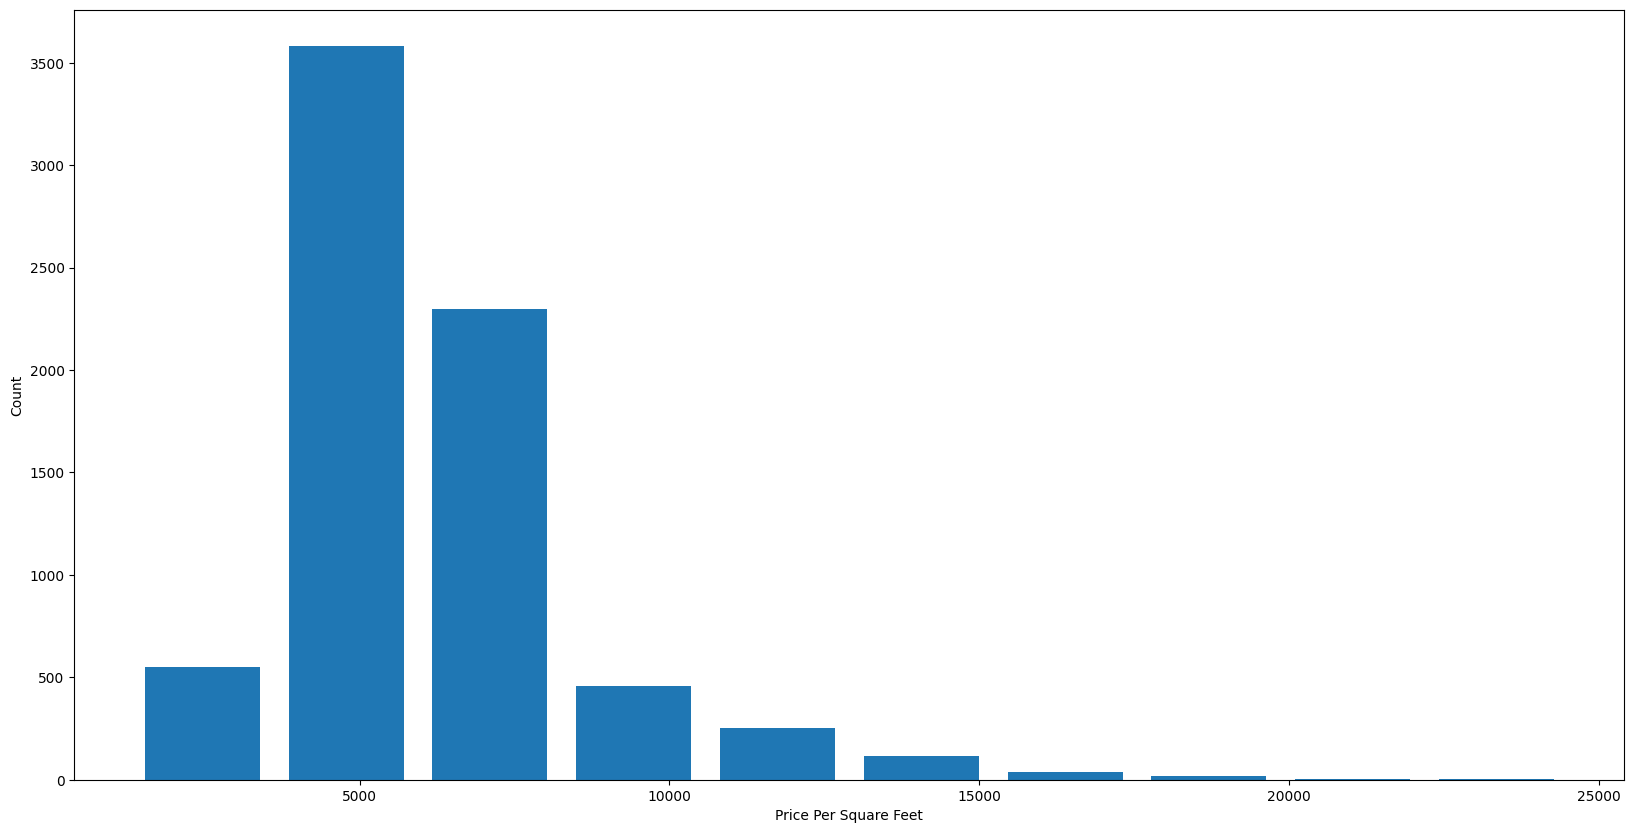

In [117]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df8.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [118]:
df8.head(1)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.00,4.00,428.00,4,15017.54


* Most properties cluster between ₹4000 and ₹7000 per sqft, meaning this is the typical market range.

* There is a smaller but noticeable group between ₹7000 and ₹10,000 per sqft, representing mid-to-high-end properties.

* Very few properties lie above ₹10,000 per sqft, which indicates luxury or premium flats.

* The distribution is right-skewed — meaning a small number of properties have extremely high prices per sqft.

* These high-value points are likely outliers, luxury projects, or unusual pricing cases.

* The histogram helps visualize why we needed outlier removal, since rare extreme values can distort averages and model training.

<h2 style='color:blue'>Outlier Removal Using Bathrooms Feature</h2>

In [119]:
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

Text(0, 0.5, 'Count')

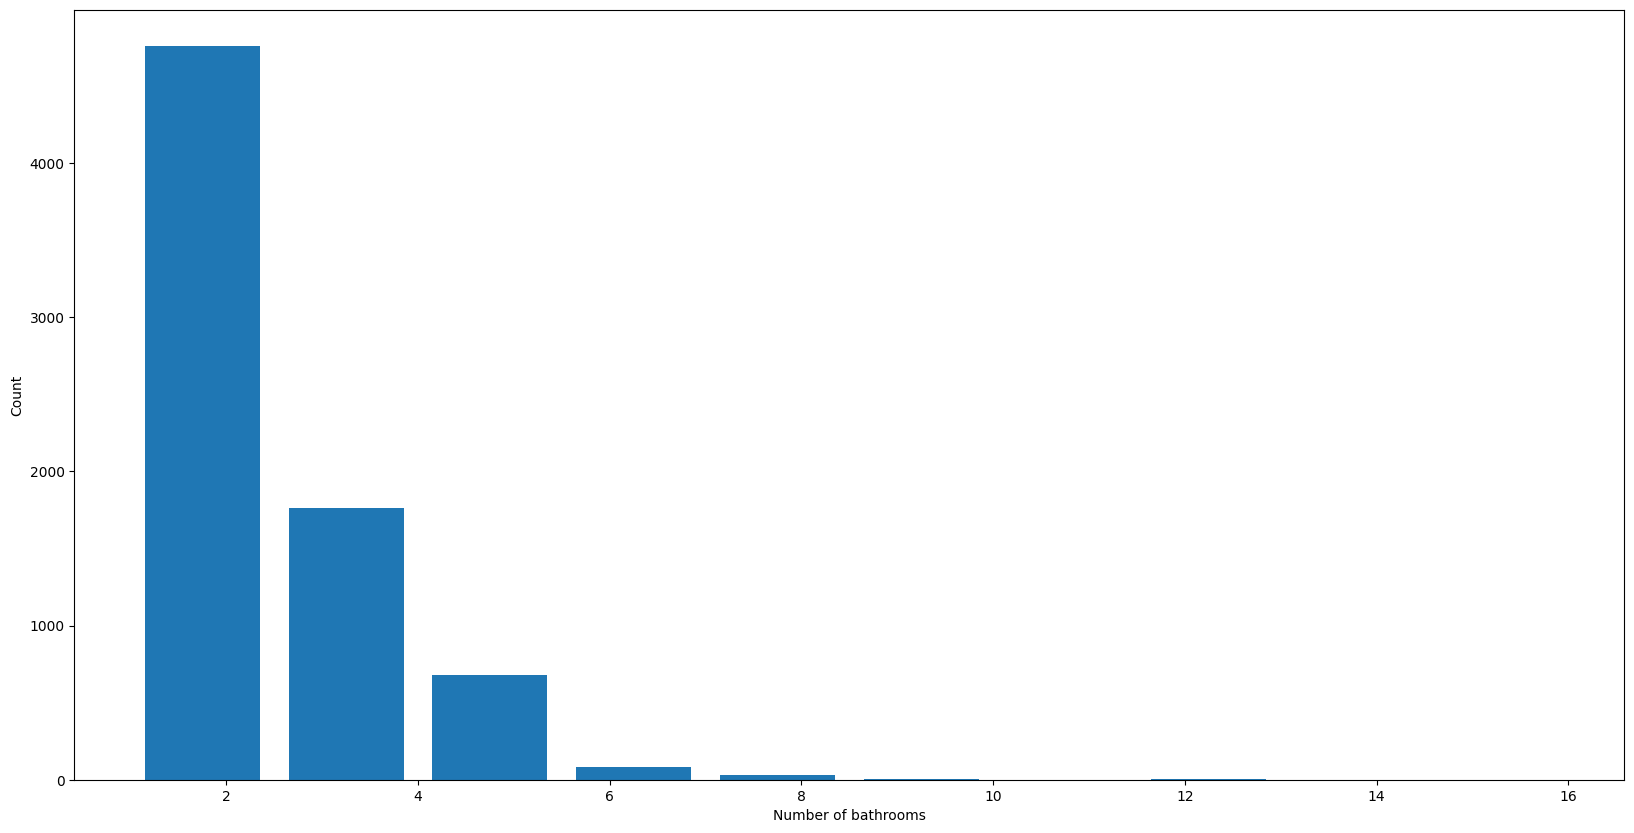

In [120]:
plt.hist(df8.bath,rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [121]:
df8[df8.bath > 10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.00,12.00,160.00,10,4000.00
8483,other,10 BHK,12000.00,12.00,525.00,10,4375.00
8572,other,16 BHK,10000.00,16.00,550.00,16,5500.00
9306,other,11 BHK,6000.00,12.00,150.00,11,2500.00
9637,other,13 BHK,5425.00,13.00,275.00,13,5069.12


**It is unusual to have 2 more bathrooms than number of bedrooms in a home**

In [122]:
df8[df8.bath > df8.bhk + 2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.00,7.00,80.00,4,3252.03
5238,Nagasandra,4 Bedroom,7000.00,8.00,450.00,4,6428.57
6711,Thanisandra,3 BHK,1806.00,6.00,116.00,3,6423.03
8408,other,6 BHK,11338.00,9.00,1000.00,6,8819.90


In [123]:
df8[df8.bath > df8.bhk + 2].shape

(4, 7)

In [124]:
df8[df8.bath >= df8.bhk + 2].shape

(78, 7)

In [125]:
df8[df8.bath < df8.bhk + 2].shape

(7239, 7)

In [126]:
df8.shape

(7317, 7)

**Again the business manager has a conversation with you (i.e. a data scientist) that if you have 4 bedroom home and even if you have bathroom in all 4 rooms plus one guest bathroom, you will have total bath = total bed + 1 max. Anything above that is an outlier or a data error and can be removed**

Should have been 7317 - 4 but we got 7239  
❌ rows where bath > bhk+2  
❌ rows where bath == bhk+2  

So 7317 - 78 = 7239

In [127]:
df9 = df8[df8.bath < df8.bhk + 2]
df9.shape

(7239, 7)

In [128]:
df9.head(2)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.00,4.00,428.00,4,15017.54
1,1st Block Jayanagar,3 BHK,1630.00,3.00,194.00,3,11901.84


In [129]:
df10 = df9.drop(['size','price_per_sqft'], axis='columns')
df10.head(3)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.00,4.00,428.00,4
1,1st Block Jayanagar,1630.00,3.00,194.00,3
2,1st Block Jayanagar,1875.00,2.00,235.00,3


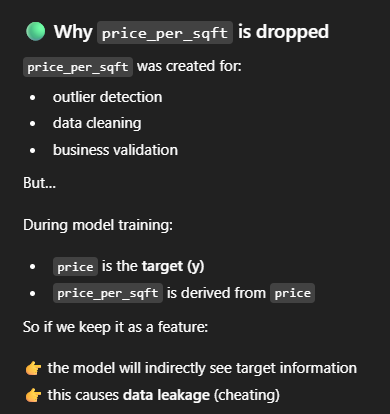

In [130]:
df10['location'].value_counts()

location
other                    1126
Whitefield                238
Sarjapur  Road            186
Electronic City           162
Raja Rajeshwari Nagar     140
                         ... 
Banjara Layout              4
Vishwapriya Layout          4
Nagasandra                  4
Vishveshwarya Layout        4
Marsur                      3
Name: count, Length: 241, dtype: int64

<h2 style='color:blue'>Use One Hot Encoding For Location</h2>

In [131]:
dummies = pd.get_dummies(df10.location)
dummies.head(3)

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [132]:
dummies.columns[0]

'1st Block Jayanagar'

In [133]:
# # Modern approach to avoid dummy variable trap
# df11 = pd.get_dummies(df10, columns=['location'], drop_first=True)
# df11.head()

* When you use pd.get_dummies(df10, columns=['location'], drop_first=True), pandas sorts the unique values in the 'location' column in alphabetical order and drops the first one.  

* So, the first location in alphabetical order (e.g., "1st Block Jayanagar" if it exists) will be dropped, and all other locations will have their own columns.

* Pandas automatically removes the original 'location' column and replaces it with the new one-hot encoded columns (except the first, which is dropped). So, you do not need to drop the 'location' column manually.

In [134]:
df11 = pd.concat([df10,dummies.drop('other',axis='columns')], axis='columns')
df11.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.00,4.00,428.00,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.00,3.00,194.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.00,2.00,235.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.00,2.00,130.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.00,2.00,148.00,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [135]:
df11.shape

(7239, 245)

In [136]:
df12 = df11.drop('location',axis='columns')
df12.head(2)

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.00,4.00,428.00,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.00,3.00,194.00,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<h2 style='color:blue'>Build a Model Now...</h2>

In [137]:
df12.shape

(7239, 244)

In [138]:
X = df12.drop(['price'],axis='columns')
X.head(3)

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.00,4.00,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.00,3.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.00,2.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [139]:
X.shape

(7239, 243)

In [140]:
y = df12.price
y.head(3)

0   428.00
1   194.00
2   235.00
Name: price, dtype: float64

In [141]:
len(y)

7239

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [143]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)

0.8629132245229449

<h2 style='color:blue'>Use K Fold cross validation to measure accuracy of our LinearRegression model</h2>

In [144]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.82702546, 0.86027005, 0.85322178, 0.8436466 , 0.85481502])

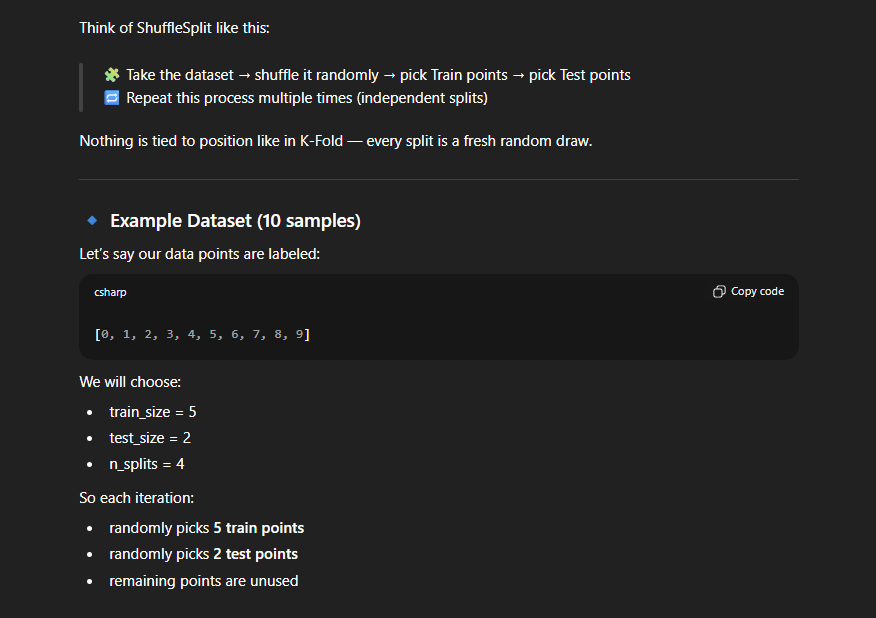

In [145]:
# # TESTING ShuffleSplit
# from sklearn.model_selection import ShuffleSplit
# import numpy as np

# X = np.arange(10)   # 10 data points: 0..9
# print(X)
# # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# ss = ShuffleSplit(n_splits=4, train_size=5, test_size=2, random_state=42)

# for i, (train_idx, test_idx) in enumerate(ss.split(X), 1):
#     print(f"Split {i}")
#     print("Train:", train_idx)
#     print("Test :", test_idx)
#     print()


#### Difference between KFold and ShuffleSplit

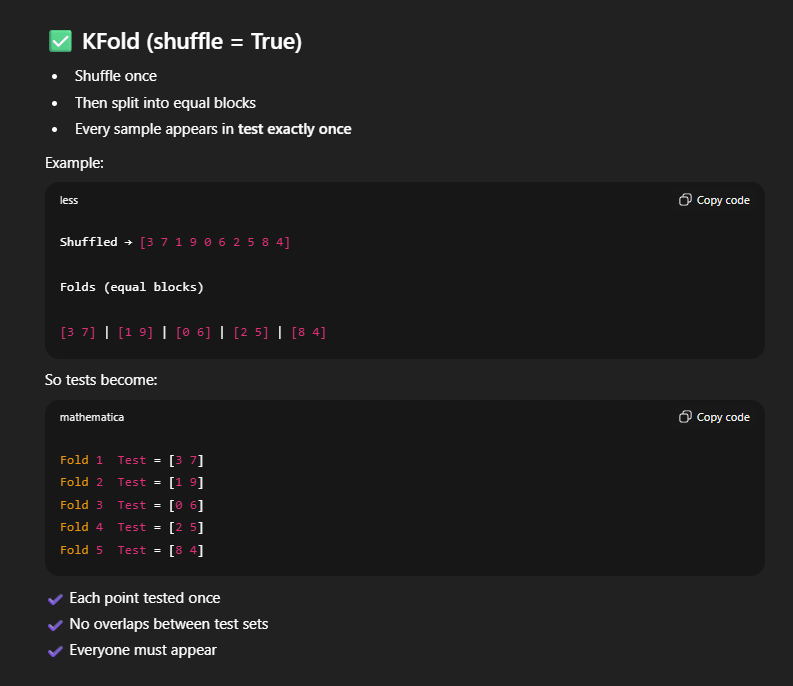  

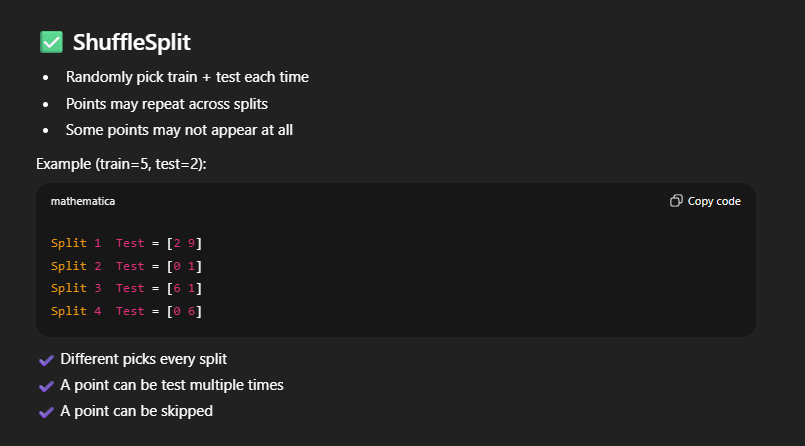

In [146]:
# # TESTING KFold
# from sklearn.model_selection import KFold
# import numpy as np

# X = np.arange(10)   # 10 samples: 0..9
# print(X)
# # [0 1 2 3 4 5 6 7 8 9]

# # total samples = 10
# # k = n_splits = 5 folds
# # 👉 Each fold must contain:
# # 10 / 5 = 2 samples per test set

# kf = KFold(n_splits=5, shuffle=False) # random_state is ignored when shuffle=False
# # kf = KFold(n_splits=5, shuffle=True)

# for i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
#     print(f"Fold {i}")
#     print("Train:", train_idx)
#     print("Test :", test_idx)
#     print()
    
# # How it takes first two samples as test data and rest as train data in first fold?


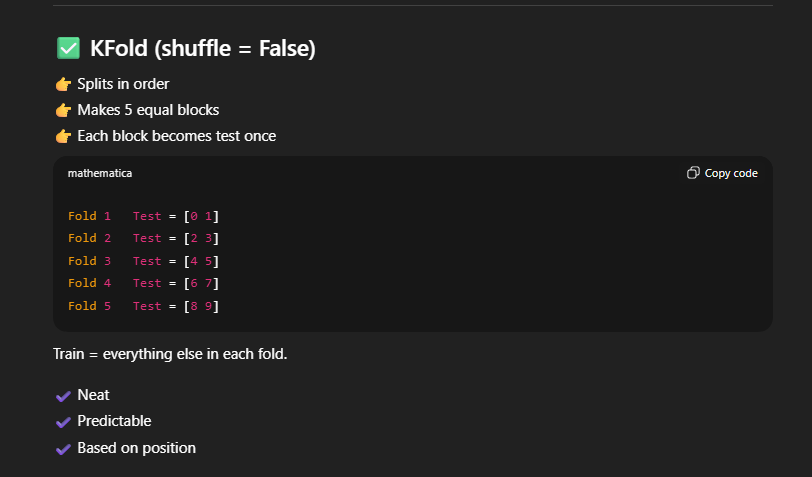  

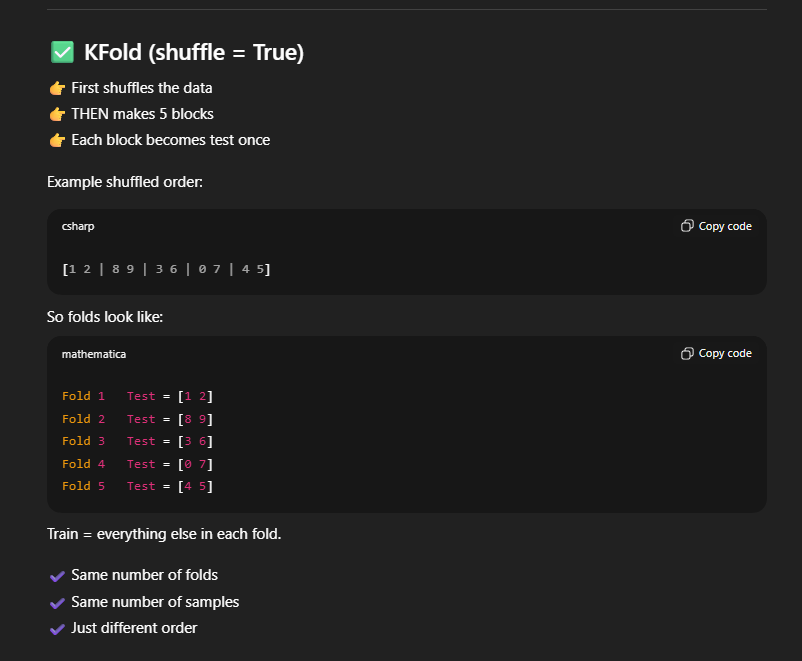

In [147]:
val = cross_val_score(LinearRegression(), X, y, cv=cv)
print(type(val))
print(val.mean())

<class 'numpy.ndarray'>
0.8477957812446629


**We can see that in 5 iterations we get a score above 80% all the time. This is pretty good but we want to test few other algorithms for regression to see if we can get even better score. We will use GridSearchCV for this purpose**  

* 👉 GridSearchCV was used because the dataset is small, models are simple, and the search space is tiny.
* 👉 Bayesian optimization is more useful when you have many hyperparameters and expensive models.

In [ ]:
## ✅ 1) K-Fold Cross Validation
# from sklearn.model_selection import KFold, cross_val_score

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(model, X, y, cv=kf)
# print(scores)

In [ ]:
## ✅ 2) Stratified K-Fold (for classification)
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(model, X, y, cv=skf)
# print(scores)

In [ ]:
# ✅ 3) Repeated K-Fold
# from sklearn.model_selection import RepeatedKFold, cross_val_score

# rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
# scores = cross_val_score(model, X, y, cv=rkf)
# print(scores)

# ✅ 4) Leave-One-Out (LOOCV)
# from sklearn.model_selection import LeaveOneOut, cross_val_score

# loo = LeaveOneOut()
# scores = cross_val_score(model, X, y, cv=loo)
# print(scores.mean())

# ✅ 5) Leave-P-Out
# from sklearn.model_selection import LeavePOut, cross_val_score

# lpo = LeavePOut(p=2)
# scores = cross_val_score(model, X, y, cv=lpo)
# print(scores.mean())
# ⚠️ Very slow for large datasets

In [ ]:
## ✅ 6) Group K-Fold
# from sklearn.model_selection import GroupKFold, cross_val_score

# gkf = GroupKFold(n_splits=5)
# scores = cross_val_score(model, X, y, groups=groups, cv=gkf)
# print(scores)


## groups = array of group IDs
## (ensures same group not in train & test)

## ✅ 7) Stratified Group K-Fold
# from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

# sgkf = StratifiedGroupKFold(n_splits=5)
# scores = cross_val_score(model, X, y, groups=groups, cv=sgkf)
# print(scores)


## Requires sklearn ≥ 1.1

## ✅ 8) TimeSeriesSplit
# from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# tscv = TimeSeriesSplit(n_splits=5)
# scores = cross_val_score(model, X, y, cv=tscv)
# print(scores)


## No shuffling — respects time order


## ✅ 9) ShuffleSplit (your notebook)
# from sklearn.model_selection import ShuffleSplit, cross_val_score

# ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
# scores = cross_val_score(model, X, y, cv=ss)
# print(scores)

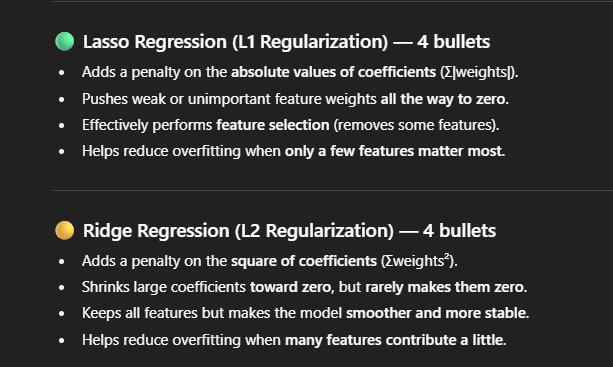

<h2 style='color:blue'>Find best model using GridSearchCV</h2>

## OLD CODE

In [ ]:
# from sklearn.model_selection import GridSearchCV

# from sklearn.linear_model import Lasso # Lasso = Linear Regression + L1 penalty
# from sklearn.linear_model import Ridge # Ridge = Linear Regression + L2 penalty
# from sklearn.tree import DecisionTreeRegressor

# def find_best_model_using_gridsearchcv(X,y):
#     algos = {
#         'linear_regression' : {
#             'model': LinearRegression(),
#             'params': {
#                 'normalize': [True, False]
#             }
#         },
#         'lasso': {
#             'model': Lasso(),
#             'params': {
#                 'alpha': [1,2],
#                 'selection': ['random', 'cyclic']
#             }
#         },
#         'decision_tree': {
#             'model': DecisionTreeRegressor(),
#             'params': {
#                 'criterion' : ['mse','friedman_mse'],
#                 'splitter': ['best','random']
#             }
#         }
#     }
#     scores = []
#     cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
#     for algo_name, config in algos.items():
#         gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
#         gs.fit(X,y)
#         scores.append({
#             'model': algo_name,
#             'best_score': gs.best_score_,
#             'best_params': gs.best_params_
#         })

#     return pd.DataFrame(scores,columns=['model','best_score','best_params'])

# find_best_model_using_gridsearchcv(X,y)

## NEW CODE

In [148]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

def find_best_model_using_gridsearchcv(X, y):

    algos = {

        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                # removed deprecated normalize param
                'fit_intercept': [True, False]
            }
        },

        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [0.1, 1, 2, 5],
                'selection': ['cyclic', 'random']
            }
        },

        'ridge': {
            'model': Ridge(),
            'params': {
                'alpha': [0.1, 1, 2, 5]
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random'],
                'max_depth': [None, 5, 10]
            }
        }
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(
            config['model'],
            config['params'],
            cv=cv,
            return_train_score=False
        )

        gs.fit(X, y)

        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])


find_best_model_using_gridsearchcv(X, y)


,model,best_score,best_params
0,linear_regression,0.85,{'fit_intercept': False}
1,lasso,0.80,"{'alpha': 0.1, 'selection': 'random'}"
2,ridge,0.85,{'alpha': 0.1}
3,decision_tree,0.73,"{'criterion': 'friedman_mse', 'max_depth': 10,..."


**Based on above results we can say that LinearRegression gives the best score. Hence we will use that.**

In [ ]:
X.head()

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.00,4.00,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.00,3.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.00,2.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.00,2.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.00,2.00,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
vv = 9

In [149]:
print(np.where(X.columns=='Not Present TEST')[0][0])

IndexError: index 0 is out of bounds for axis 0 with size 0

In [150]:
print(np.where(X.columns=='1st Phase JP Nagar')[0][0])

4


In [161]:
print(np.where(X.columns=='1st Phase JP Nagar')[0])

[4]


In [162]:
print(np.where(X.columns=='1st Phase JP Nagar'))

(array([4]),)


In [166]:
print(np.zeros(1))

[0.]


In [169]:
print(np.zeros(5))

[0. 0. 0. 0. 0.]


In [170]:
X.head()

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.00,4.00,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.00,3.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.00,2.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.00,2.00,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.00,2.00,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<h2 style='color:blue'>Test the model for few properties</h2>

In [160]:
# Prediction helper function used after training the model.
# 👉 It builds a feature vector in the same format as the training data, fills the input values, and asks the model to predict the apartment price.
def predict_price(location, sqft, bath, bhk):
    x = np.zeros(len(X.columns))
    
    x[0] = sqft
    x[1] = bath
    x[2] = bhk

    # find location index safely
    matches = np.where(X.columns == location)[0]

    if len(matches) > 0:      # location exists in columns
        loc_index = matches[0]
        x[loc_index] = 1
    else:
        # location not present → treat as baseline / unknown
        # (leave all zeros for location fields)
        pass

    return lr_clf.predict([x])[0]


In [161]:
predict_price('1st Phase JP Nagar',1000, 2, 2)

c:\Users\subin\.conda\envs\svm\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(83.86570258311183)

In [162]:
predict_price('1st Phase JP Nagar',1000, 3, 3)

c:\Users\subin\.conda\envs\svm\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(86.08062284985955)

In [163]:
predict_price('Indira Nagar',1000, 2, 2)

c:\Users\subin\.conda\envs\svm\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(193.31197733179573)

In [164]:
predict_price('Not Present TEST',1000, 2, 2)

c:\Users\subin\.conda\envs\svm\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(81.4153258841424)

In [155]:
predict_price('Indira Nagar',1000, 3, 3)

c:\Users\subin\.conda\envs\svm\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(195.52689759854343)

<h2 style='color:blue'>Export the tested model to a pickle file</h2>

In [177]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lr_clf,f)

<h2 style='color:blue'>Export location and column information to a file that will be useful later on in our prediction application</h2>

In [178]:
import json
columns = {
    'data_columns' : [col.lower() for col in X.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))